# Entropy Analysis for Experiment Results
This notebook analyzes entropy metrics from experiment rollouts and visualizes patterns between correct and incorrect solutions.

## 1. Imports and Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from utils import *

In [2]:
# sbatch --job-name=aim_1 --constraint=RTX_4090 experiment.sh --problems "0:10" --num_rollouts 50
# sbatch --job-name=aim_2 --constraint=RTX_4090 experiment.sh --problems "10:20" --num_rollouts 50
# sbatch --job-name=aim_3 --constraint=RTX_4090 experiment.sh --problems "20:30" --num_rollouts 50

# sbatch --job-name=aim_1c --constraint=RTX_4090 experiment.sh --problems "0:10" --num_rollouts 50 --condition_on_final_answer
# sbatch --job-name=aim_2c --constraint=RTX_4090 experiment.sh --problems "10:20" --num_rollouts 50 --condition_on_final_answer
# sbatch --job-name=aim_3c --constraint=RTX_4090 experiment.sh --problems "20:30" --num_rollouts 50 --condition_on_final_answer

## 2. Load Experiment Data

In [5]:
# Load experiment results
experiment_id = 'aim_1_20251113_025853'
with open(f'experiments/{experiment_id}/experiment.json', 'r') as f:
    experiment = json.load(f)

# Find problem key
problem_idx = 0
problem_key = next(k for k in experiment['results'] if experiment['results'][k]['dataset_index'] == problem_idx)
num_rollouts = len(experiment['results'][problem_key]['rollouts'])

print(f"Loaded experiment with {num_rollouts} rollouts for problem {problem_idx}")

Loaded experiment with 50 rollouts for problem 0


## 3. Define Metric Functions

In [6]:
def compute_per_step_metrics(entropy, window=10):
    """Compute per-step metrics for entropy sequence."""
    n = len(entropy)
    
    # Cumulative sum
    cumsum = np.cumsum(entropy)
    
    # Rolling volatility (std)
    volatility = np.full(n, np.nan)
    for i in range(window, n):
        volatility[i] = np.std(entropy[i-window:i])
    
    # Rolling slope
    slope = np.full(n, np.nan)
    for i in range(window, n):
        slope[i] = np.polyfit(range(window), entropy[i-window:i], 1)[0]
    
    return {
        'cumsum': cumsum,
        'volatility': volatility,
        'slope': slope
    }

In [7]:
def compute_global_metrics(entropy, window=10):
    """Compute global metrics for entropy sequence."""
    # Basic statistics
    mean_val = np.mean(entropy)
    median_val = np.median(entropy)
    std_val = np.std(entropy)
    
    # Compute deltas
    deltas = np.diff(entropy)
    abs_deltas = np.abs(deltas)
    
    # Spikes: tokens where both incoming and outgoing deltas are in top 5%
    threshold_95 = np.percentile(abs_deltas, 95)
    num_spikes = 0
    for i in range(1, len(entropy) - 1):
        delta_prev = abs(entropy[i] - entropy[i-1])
        delta_next = abs(entropy[i+1] - entropy[i])
        if delta_prev >= threshold_95 and delta_next >= threshold_95:
            num_spikes += 1
    
    # Phase shifts: detect significant changes in rolling mean/std
    rolling_mean = np.full(len(entropy), np.nan)
    rolling_std = np.full(len(entropy), np.nan)
    for i in range(window, len(entropy)):
        rolling_mean[i] = np.mean(entropy[i-window:i])
        rolling_std[i] = np.std(entropy[i-window:i])
    
    # Detect phase shifts: large changes in rolling statistics
    mean_changes = np.abs(np.diff(rolling_mean[window:]))
    std_changes = np.abs(np.diff(rolling_std[window:]))
    
    mean_change_threshold = np.percentile(mean_changes[~np.isnan(mean_changes)], 90) if len(mean_changes) > 0 else 0
    std_change_threshold = np.percentile(std_changes[~np.isnan(std_changes)], 90) if len(std_changes) > 0 else 0
    
    phase_shifts = 0
    for i in range(len(mean_changes)):
        if (not np.isnan(mean_changes[i]) and mean_changes[i] >= mean_change_threshold) or \
           (not np.isnan(std_changes[i]) and std_changes[i] >= std_change_threshold):
            phase_shifts += 1
    
    return {
        'mean': mean_val,
        'median': median_val,
        'std': std_val,
        'num_spikes': num_spikes,
        'phase_shifts': phase_shifts
    }

## 4. Process All Rollouts

In [8]:
# Load all rollouts and compute metrics
rollout_data = []
for rollout_num in range(num_rollouts):
    with open(f'experiments/{experiment_id}/problem_{problem_idx}/rollout_{rollout_num}/graph_structure.json', 'r') as f:
        data = json.load(f)
    
    entropy = np.array([item['metric_value'] for item in data['final_sequence']])
    is_correct = experiment['results'][problem_key]['rollouts'][rollout_num]['is_correct']
    
    # Compute metrics
    per_step = compute_per_step_metrics(entropy)
    global_metrics = compute_global_metrics(entropy)
    
    rollout_data.append({
        'rollout_num': rollout_num,
        'entropy': entropy,
        'is_correct': is_correct,
        'per_step': per_step,
        'global': global_metrics
    })

print("Computed all metrics for all rollouts")
print(f"Total rollouts: {len(rollout_data)}")
print(f"Correct: {sum(1 for r in rollout_data if r['is_correct'])}")
print(f"Wrong: {sum(1 for r in rollout_data if not r['is_correct'])}")

Computed all metrics for all rollouts
Total rollouts: 50
Correct: 22
Wrong: 28


In [9]:
import pandas as pd

success_rollout_data = [rollout for rollout in rollout_data if rollout['is_correct']]
fail_rollout_data = [rollout for rollout in rollout_data if not rollout['is_correct']]

success_global_metrics = {
    'mean': np.mean([rollout['global']['mean'] for rollout in success_rollout_data]),
    'median': np.mean([rollout['global']['median'] for rollout in success_rollout_data]),
    'std': np.mean([rollout['global']['std'] for rollout in success_rollout_data]),
    'num_spikes': np.mean([rollout['global']['num_spikes'] for rollout in success_rollout_data]),
    'phase_shifts': np.mean([rollout['global']['phase_shifts'] for rollout in success_rollout_data])
}

fail_global_metrics = {
    'mean': np.mean([rollout['global']['mean'] for rollout in fail_rollout_data]),
    'median': np.mean([rollout['global']['median'] for rollout in fail_rollout_data]),
    'std': np.mean([rollout['global']['std'] for rollout in fail_rollout_data]),
    'num_spikes': np.mean([rollout['global']['num_spikes'] for rollout in fail_rollout_data]),
    'phase_shifts': np.mean([rollout['global']['phase_shifts'] for rollout in fail_rollout_data])
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Successful Rollouts': success_global_metrics,
    'Failed Rollouts': fail_global_metrics
})

# Add a difference column
comparison_df['Difference'] = comparison_df['Successful Rollouts'] - comparison_df['Failed Rollouts']

# Display the DataFrame
print("\nGlobal Metrics Comparison: Successful vs Failed Rollouts")
print("="*70)
comparison_df


Global Metrics Comparison: Successful vs Failed Rollouts


,Successful Rollouts,Failed Rollouts,Difference
mean,0.082408,0.115153,-0.032746
median,0.000053,0.000610,-0.000556
std,0.234532,0.280692,-0.046161
num_spikes,22.727273,22.464286,0.262987
phase_shifts,145.863636,162.750000,-16.886364


## 5. Visualization 1: Raw Entropies

### 5A. Original Entropy Plot

/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/3437214854.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_correct.legend(loc='upper right', fontsize=9)
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/3437214854.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_wrong.legend(loc='upper right', fontsize=9)


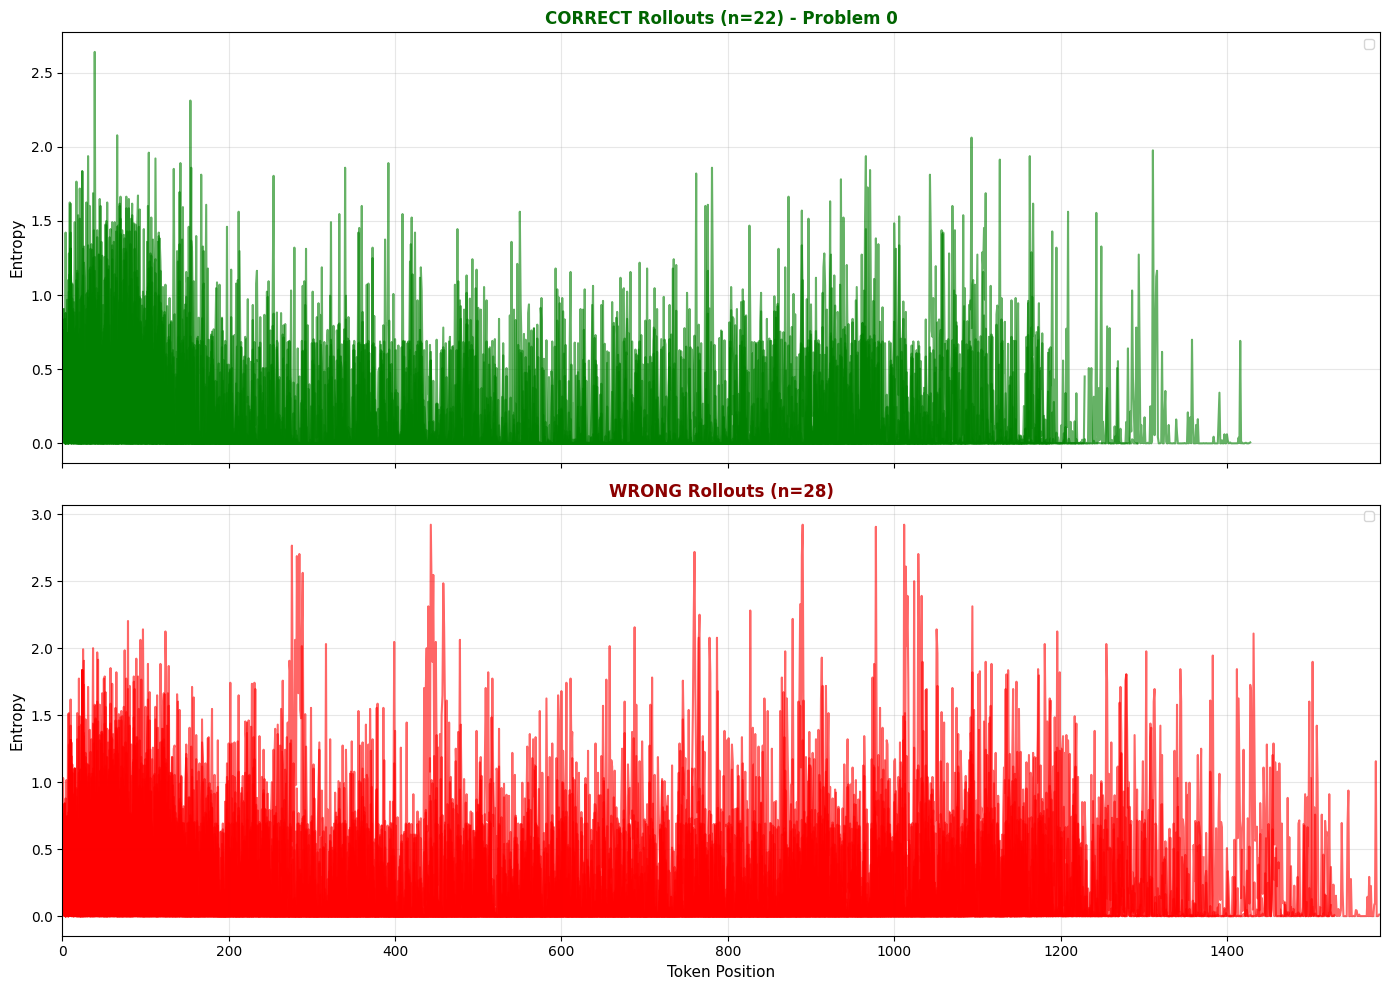

In [11]:
# Split rollouts by correctness
correct_rollouts = [r for r in rollout_data if r['is_correct']]
wrong_rollouts = [r for r in rollout_data if not r['is_correct']]

# Find max token position across all rollouts for alignment
max_tokens = max(len(r['entropy']) for r in rollout_data)

# Create figure with two aligned panels
fig, (ax_correct, ax_wrong) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top panel: Correct rollouts
if correct_rollouts:
    for rollout in correct_rollouts:
        ax_correct.plot(rollout['entropy'], linewidth=1.5, color='green', alpha=0.6)
    ax_correct.set_ylabel('Entropy', fontsize=11)
    ax_correct.set_title(f'CORRECT Rollouts (n={len(correct_rollouts)}) - Problem {problem_idx}', 
                        fontsize=12, fontweight='bold', color='darkgreen')
    ax_correct.legend(loc='upper right', fontsize=9)
    ax_correct.grid(True, alpha=0.3)
else:
    ax_correct.text(0.5, 0.5, 'No correct rollouts', ha='center', va='center', 
                   transform=ax_correct.transAxes, fontsize=14, color='gray')
    ax_correct.set_ylabel('Entropy', fontsize=11)
    ax_correct.set_title(f'CORRECT Rollouts (n=0) - Problem {problem_idx}', 
                        fontsize=12, fontweight='bold', color='darkgreen')

# Bottom panel: Wrong rollouts
if wrong_rollouts:
    for rollout in wrong_rollouts:
        ax_wrong.plot(rollout['entropy'], linewidth=1.5, color='red', alpha=0.6)
    ax_wrong.set_ylabel('Entropy', fontsize=11)
    ax_wrong.set_title(f'WRONG Rollouts (n={len(wrong_rollouts)})', 
                      fontsize=12, fontweight='bold', color='darkred')
    ax_wrong.legend(loc='upper right', fontsize=9)
    ax_wrong.grid(True, alpha=0.3)
else:
    ax_wrong.text(0.5, 0.5, 'No wrong rollouts', ha='center', va='center', 
                 transform=ax_wrong.transAxes, fontsize=14, color='gray')
    ax_wrong.set_ylabel('Entropy', fontsize=11)
    ax_wrong.set_title(f'WRONG Rollouts (n=0)', 
                      fontsize=12, fontweight='bold', color='darkred')

# Set aligned x-axis range for both panels
ax_wrong.set_xlabel('Token Position', fontsize=11)
ax_wrong.set_xlim(0, max_tokens)

plt.tight_layout()
plt.show()

### 5b. Enhanced Entropy Visualization (with aggregated statistics)

/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/557525430.py:25: RuntimeWarning: Mean of empty slice
  mean_entropy = np.nanmean(padded, axis=0)
/Users/adityashukzy/Documents/GitHub/MAT1510-Project/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


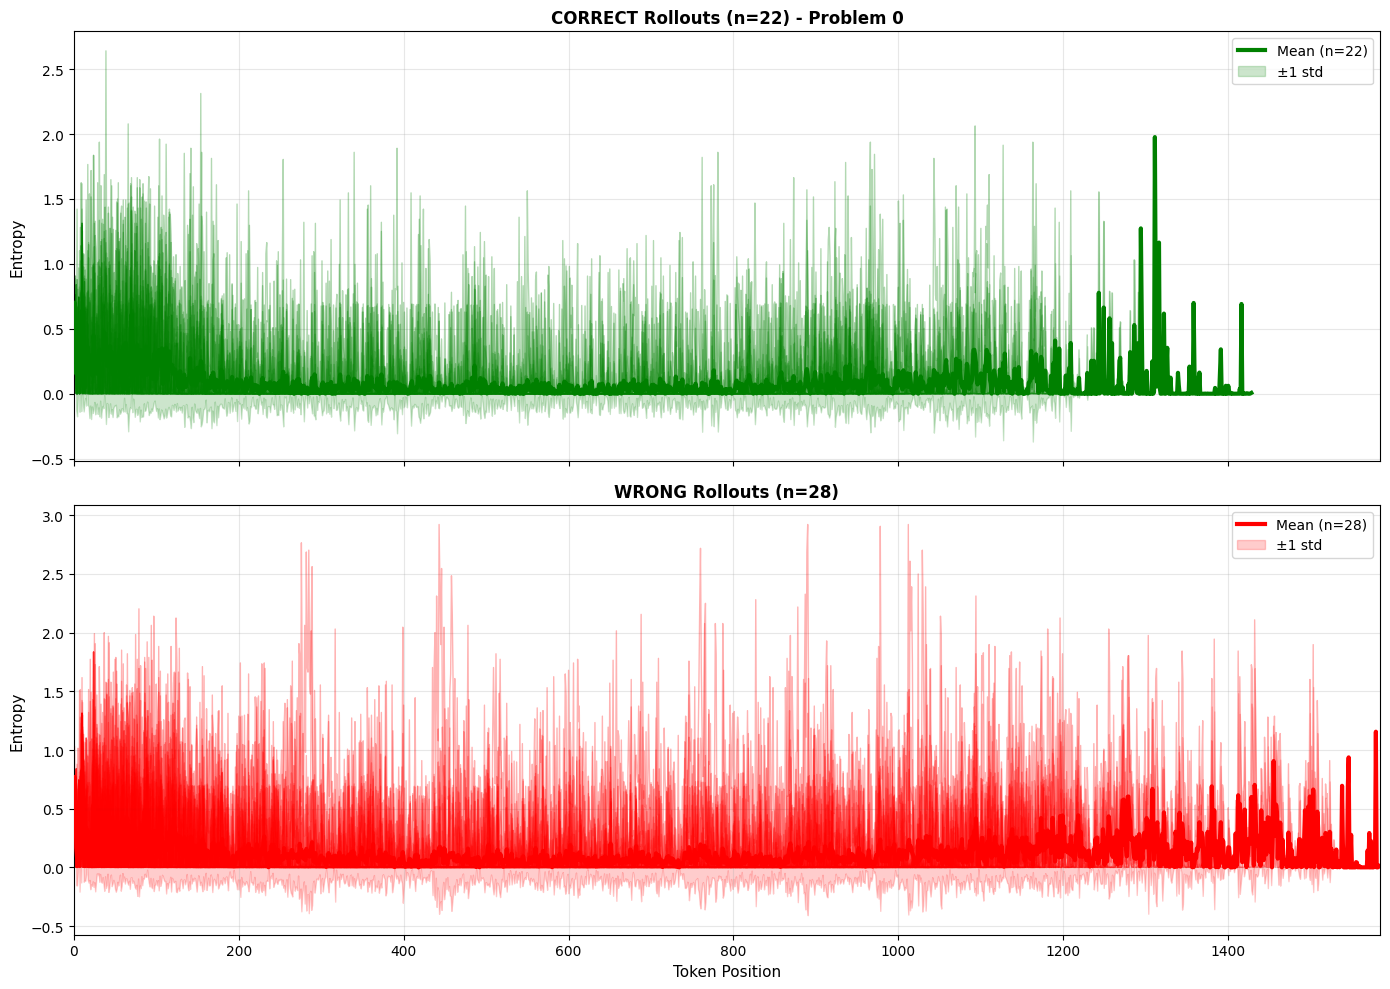

In [12]:
# Enhanced visualization with mean/confidence bands
correct_rollouts = [r for r in rollout_data if r['is_correct']]
wrong_rollouts = [r for r in rollout_data if not r['is_correct']]

max_tokens = max(len(r['entropy']) for r in rollout_data)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

def plot_with_statistics(ax, rollouts, color, title):
    """Plot individual lines with mean and confidence bands"""
    if not rollouts:
        ax.text(0.5, 0.5, 'No rollouts', ha='center', va='center', 
               transform=ax.transAxes, fontsize=14, color='gray')
        ax.set_title(title, fontsize=12, fontweight='bold')
        return
    
    # Pad sequences to max length with NaN
    padded = np.full((len(rollouts), max_tokens), np.nan)
    for i, rollout in enumerate(rollouts):
        padded[i, :len(rollout['entropy'])] = rollout['entropy']
        # Plot individual lines with lower opacity
        ax.plot(rollout['entropy'], linewidth=1, color=color, alpha=0.3)
    
    # Compute mean and std at each position (ignoring NaN)
    mean_entropy = np.nanmean(padded, axis=0)
    std_entropy = np.nanstd(padded, axis=0)
    
    # Plot mean line (bold)
    valid_positions = ~np.isnan(mean_entropy)
    positions = np.arange(max_tokens)[valid_positions]
    ax.plot(positions, mean_entropy[valid_positions], linewidth=3, color=color, 
           label=f'Mean (n={len(rollouts)})', alpha=1.0, zorder=10)
    
    # Plot confidence band (mean ± 1 std)
    ax.fill_between(positions, 
                    mean_entropy[valid_positions] - std_entropy[valid_positions],
                    mean_entropy[valid_positions] + std_entropy[valid_positions],
                    color=color, alpha=0.2, label='±1 std')
    
    ax.set_ylabel('Entropy', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

# Plot both panels
plot_with_statistics(axes[0], correct_rollouts, 'green', 
                    f'CORRECT Rollouts (n={len(correct_rollouts)}) - Problem {problem_idx}')
plot_with_statistics(axes[1], wrong_rollouts, 'red', 
                    f'WRONG Rollouts (n={len(wrong_rollouts)})')

axes[1].set_xlabel('Token Position', fontsize=11)
axes[1].set_xlim(0, max_tokens)

plt.tight_layout()
plt.show()

### 5c. Direct Comparison: Mean Entropy Overlay

/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/4192956594.py:18: RuntimeWarning: Mean of empty slice
  return np.nanmean(padded, axis=0), np.nanstd(padded, axis=0)


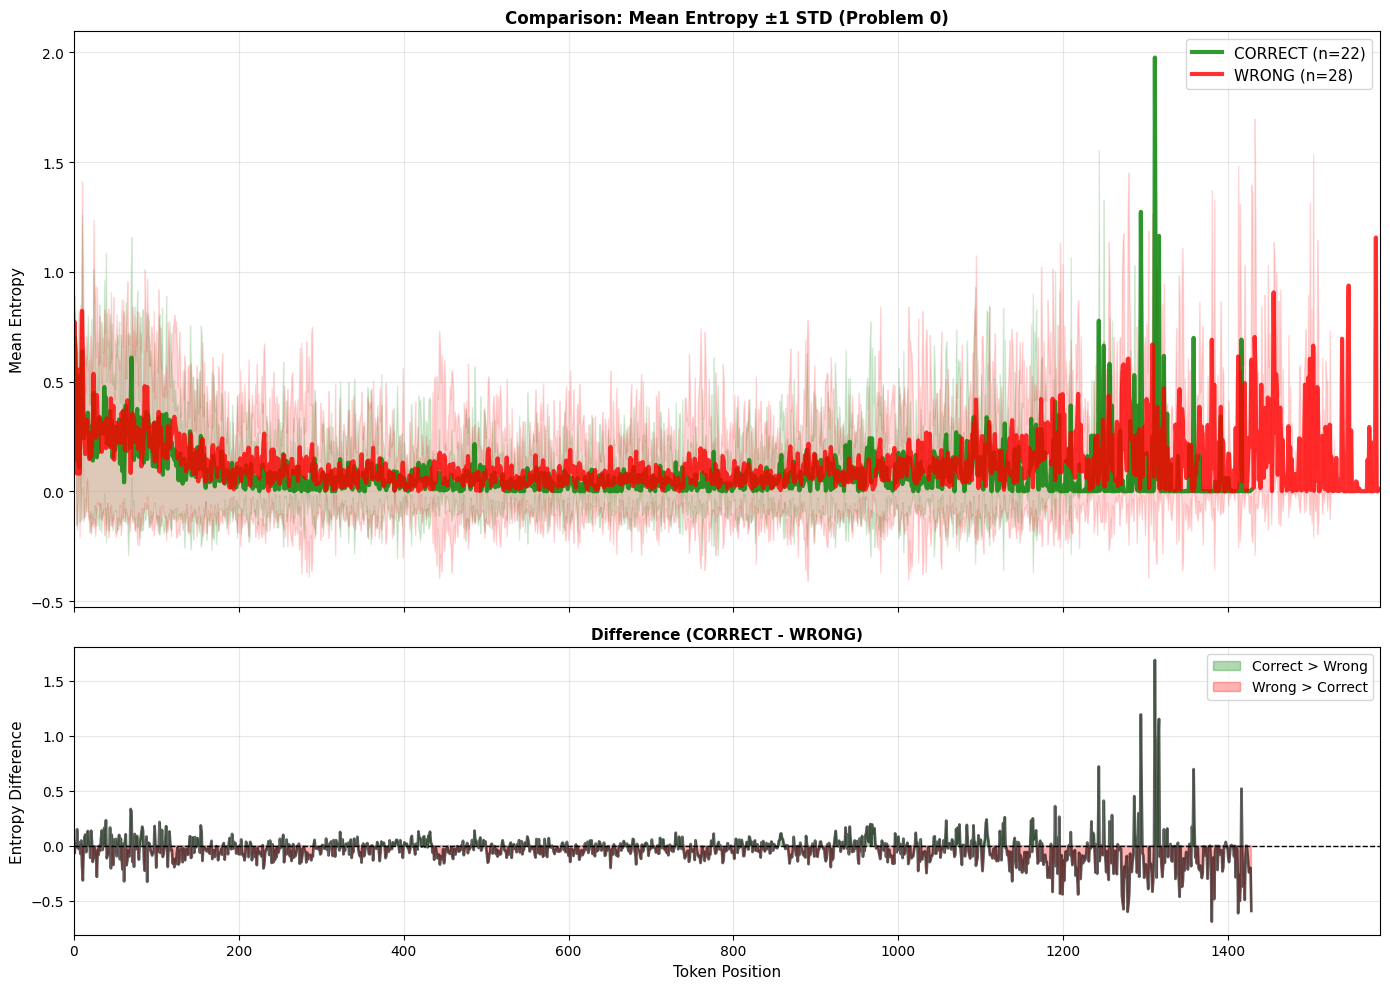

In [13]:
# Direct comparison with difference plot
correct_rollouts = [r for r in rollout_data if r['is_correct']]
wrong_rollouts = [r for r in rollout_data if not r['is_correct']]

max_tokens = max(len(r['entropy']) for r in rollout_data)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                         gridspec_kw={'height_ratios': [2, 1]})

# Top panel: Overlaid mean entropy
ax_overlay = axes[0]

def compute_mean_entropy(rollouts, max_len):
    """Compute mean entropy across rollouts"""
    padded = np.full((len(rollouts), max_len), np.nan)
    for i, rollout in enumerate(rollouts):
        padded[i, :len(rollout['entropy'])] = rollout['entropy']
    return np.nanmean(padded, axis=0), np.nanstd(padded, axis=0)

if correct_rollouts:
    mean_correct, std_correct = compute_mean_entropy(correct_rollouts, max_tokens)
    valid = ~np.isnan(mean_correct)
    pos = np.arange(max_tokens)[valid]
    ax_overlay.plot(pos, mean_correct[valid], linewidth=3, color='green', 
                   label=f'CORRECT (n={len(correct_rollouts)})', alpha=0.8)
    ax_overlay.fill_between(pos, mean_correct[valid] - std_correct[valid],
                           mean_correct[valid] + std_correct[valid],
                           color='green', alpha=0.15)

if wrong_rollouts:
    mean_wrong, std_wrong = compute_mean_entropy(wrong_rollouts, max_tokens)
    valid = ~np.isnan(mean_wrong)
    pos = np.arange(max_tokens)[valid]
    ax_overlay.plot(pos, mean_wrong[valid], linewidth=3, color='red', 
                   label=f'WRONG (n={len(wrong_rollouts)})', alpha=0.8)
    ax_overlay.fill_between(pos, mean_wrong[valid] - std_wrong[valid],
                           mean_wrong[valid] + std_wrong[valid],
                           color='red', alpha=0.15)

ax_overlay.set_ylabel('Mean Entropy', fontsize=11)
ax_overlay.set_title(f'Comparison: Mean Entropy ±1 STD (Problem {problem_idx})', 
                    fontsize=12, fontweight='bold')
ax_overlay.legend(loc='upper right', fontsize=11)
ax_overlay.grid(True, alpha=0.3)

# Bottom panel: Difference (Correct - Wrong)
ax_diff = axes[1]

if correct_rollouts and wrong_rollouts:
    # Find common valid positions
    valid_both = ~(np.isnan(mean_correct) | np.isnan(mean_wrong))
    pos = np.arange(max_tokens)[valid_both]
    diff = mean_correct[valid_both] - mean_wrong[valid_both]
    
    # Plot difference with color-coded regions
    ax_diff.fill_between(pos, 0, diff, where=(diff >= 0), 
                        color='green', alpha=0.3, label='Correct > Wrong')
    ax_diff.fill_between(pos, 0, diff, where=(diff < 0), 
                        color='red', alpha=0.3, label='Wrong > Correct')
    ax_diff.plot(pos, diff, linewidth=2, color='black', alpha=0.6)
    ax_diff.axhline(y=0, color='black', linestyle='--', linewidth=1)
    
    ax_diff.set_ylabel('Entropy Difference', fontsize=11)
    ax_diff.set_title('Difference (CORRECT - WRONG)', fontsize=11, fontweight='bold')
    ax_diff.legend(loc='upper right', fontsize=10)
    ax_diff.grid(True, alpha=0.3)
else:
    ax_diff.text(0.5, 0.5, 'Need both correct and wrong rollouts for comparison', 
                ha='center', va='center', transform=ax_diff.transAxes, 
                fontsize=12, color='gray')
    ax_diff.set_ylabel('Entropy Difference', fontsize=11)

ax_diff.set_xlabel('Token Position', fontsize=11)
ax_diff.set_xlim(0, max_tokens)

plt.tight_layout()
plt.show()

## 6. Visualization 2: Per-step Metrics

/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/1922999919.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper left')
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/1922999919.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='upper right')
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/1922999919.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc='upper right')


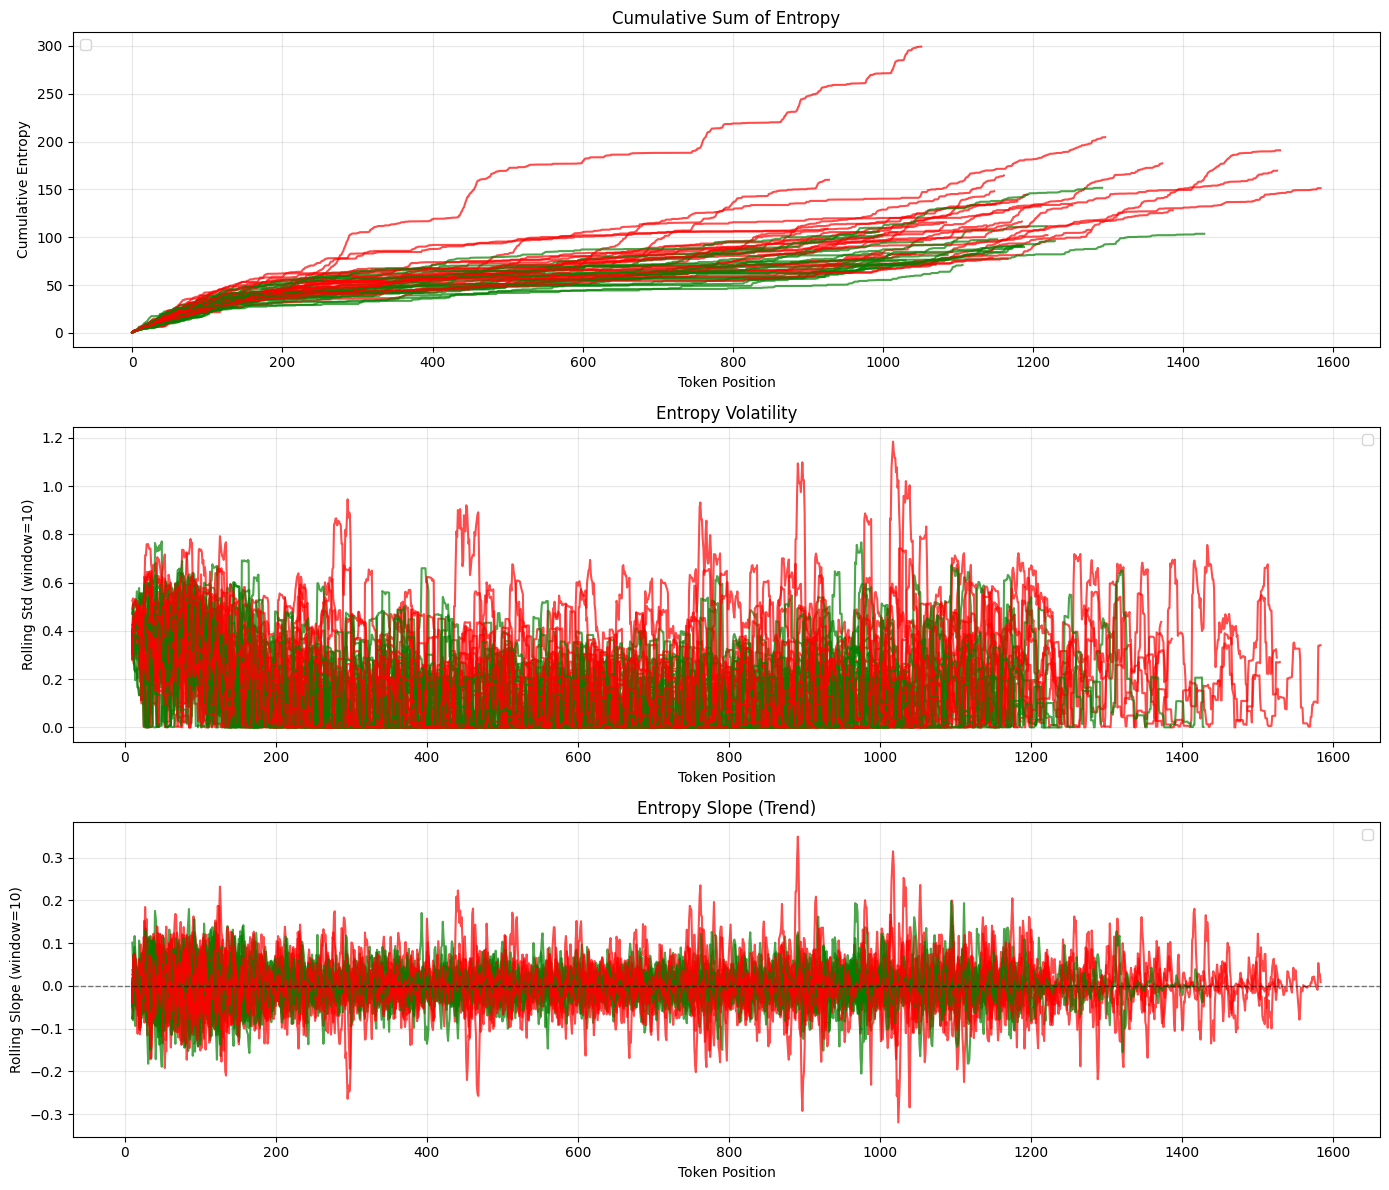

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Cumulative Sum
for rollout in rollout_data:
    color = 'green' if rollout['is_correct'] else 'red'
    label = f"Rollout {rollout['rollout_num']}"
    axes[0].plot(rollout['per_step']['cumsum'], linewidth=1.5, color=color, alpha=0.7)
axes[0].set_xlabel('Token Position')
axes[0].set_ylabel('Cumulative Entropy')
axes[0].set_title('Cumulative Sum of Entropy')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Volatility
for rollout in rollout_data:
    color = 'green' if rollout['is_correct'] else 'red'
    label = f"Rollout {rollout['rollout_num']}"
    axes[1].plot(rollout['per_step']['volatility'], linewidth=1.5, color=color, alpha=0.7)
axes[1].set_xlabel('Token Position')
axes[1].set_ylabel('Rolling Std (window=10)')
axes[1].set_title('Entropy Volatility')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Slope
for rollout in rollout_data:
    color = 'green' if rollout['is_correct'] else 'red'
    label = f"Rollout {rollout['rollout_num']}"
    axes[2].plot(rollout['per_step']['slope'], linewidth=1.5, color=color, alpha=0.7)
axes[2].set_xlabel('Token Position')
axes[2].set_ylabel('Rolling Slope (window=10)')
axes[2].set_title('Entropy Slope (Trend)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Visualization 3: Global Metrics - Box Plots

/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/1425391572.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['Correct', 'Wrong'], patch_artist=True)
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/1425391572.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['Correct', 'Wrong'], patch_artist=True)
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_86722/1425391572.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['Correct', 'Wrong'], patch_artist=T

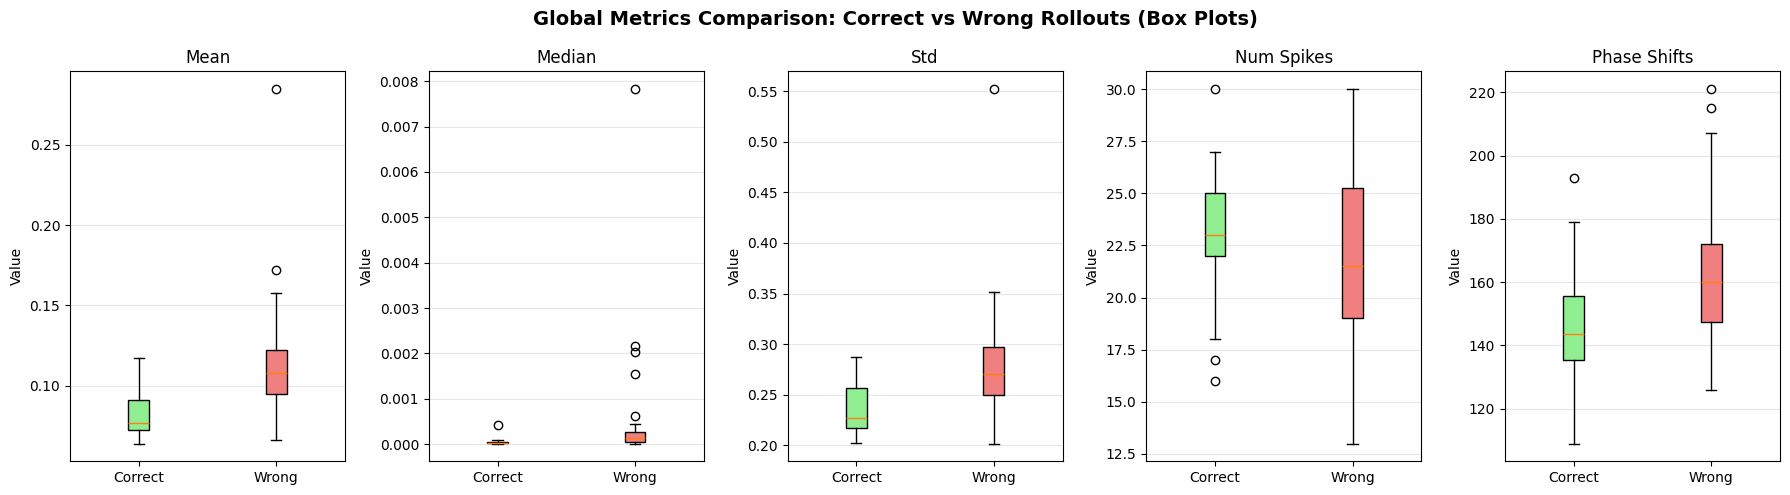

In [15]:
# Separate data by correctness
correct_data = [r for r in rollout_data if r['is_correct']]
wrong_data = [r for r in rollout_data if not r['is_correct']]

metrics_to_plot = ['mean', 'median', 'std', 'num_spikes', 'phase_shifts']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

for idx, metric in enumerate(metrics_to_plot):
    correct_values = [r['global'][metric] for r in correct_data]
    wrong_values = [r['global'][metric] for r in wrong_data]
    
    box_data = [correct_values, wrong_values]
    bp = axes[idx].boxplot(box_data, labels=['Correct', 'Wrong'], patch_artist=True)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    axes[idx].set_title(f'{metric.replace("_", " ").title()}')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Global Metrics Comparison: Correct vs Wrong Rollouts (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualization 4: Global Metrics - Bar Charts

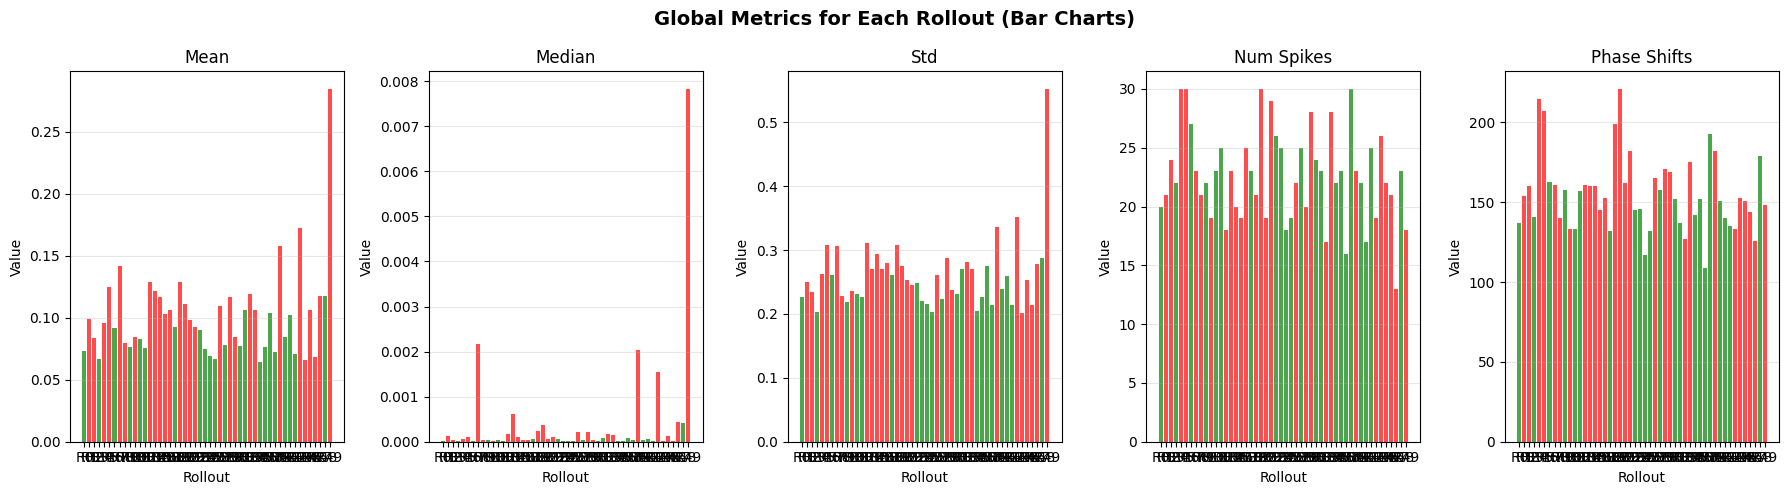

In [16]:
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

x_pos = np.arange(num_rollouts)
for idx, metric in enumerate(metrics_to_plot):
    values = [r['global'][metric] for r in rollout_data]
    colors = ['green' if r['is_correct'] else 'red' for r in rollout_data]
    
    axes[idx].bar(x_pos, values, color=colors, alpha=0.7)
    axes[idx].set_title(f'{metric.replace("_", " ").title()}')
    axes[idx].set_xlabel('Rollout')
    axes[idx].set_ylabel('Value')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels([f'R{i}' for i in range(num_rollouts)])
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Global Metrics for Each Rollout (Bar Charts)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Print Summary

In [17]:
print("\n" + "="*80)
print("GLOBAL METRICS SUMMARY")
print("="*80)
for rollout in rollout_data:
    status = "CORRECT" if rollout['is_correct'] else "WRONG"
    print(f"\nRollout {rollout['rollout_num']} ({status}):")
    for metric, value in rollout['global'].items():
        print(f"  {metric}: {value:.4f}" if isinstance(value, float) else f"  {metric}: {value}")


GLOBAL METRICS SUMMARY

Rollout 0 (CORRECT):
  mean: 0.0735
  median: 0.0000
  std: 0.2266
  num_spikes: 20
  phase_shifts: 137

Rollout 1 (WRONG):
  mean: 0.0987
  median: 0.0001
  std: 0.2506
  num_spikes: 21
  phase_shifts: 154

Rollout 2 (WRONG):
  mean: 0.0838
  median: 0.0000
  std: 0.2342
  num_spikes: 24
  phase_shifts: 160

Rollout 3 (CORRECT):
  mean: 0.0665
  median: 0.0000
  std: 0.2028
  num_spikes: 22
  phase_shifts: 141

Rollout 4 (WRONG):
  mean: 0.0955
  median: 0.0001
  std: 0.2624
  num_spikes: 30
  phase_shifts: 215

Rollout 5 (WRONG):
  mean: 0.1248
  median: 0.0001
  std: 0.3073
  num_spikes: 30
  phase_shifts: 207

Rollout 6 (CORRECT):
  mean: 0.0915
  median: 0.0000
  std: 0.2610
  num_spikes: 27
  phase_shifts: 163

Rollout 7 (WRONG):
  mean: 0.1417
  median: 0.0022
  std: 0.3068
  num_spikes: 23
  phase_shifts: 161

Rollout 8 (WRONG):
  mean: 0.0793
  median: 0.0000
  std: 0.2273
  num_spikes: 21
  phase_shifts: 140

Rollout 9 (CORRECT):
  mean: 0.0767
  medi